   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 21.3 MB/s eta 0:00:00
GPU detectada: Tesla T4. Tudo pronto.
Sucesso: Processando as 95 linhas para a auditoria.

Carregando o modelo Llama 3.1... (Este processo leva alguns minutos)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]


Iniciando auditoria probabilística...


Auditando trechos: 100%|██████████| 95/95 [01:18<00:00,  1.20it/s]



--- RESULTADO DA AUDITORIA ---
Expected Calibration Error (ECE) médio: 52.88%


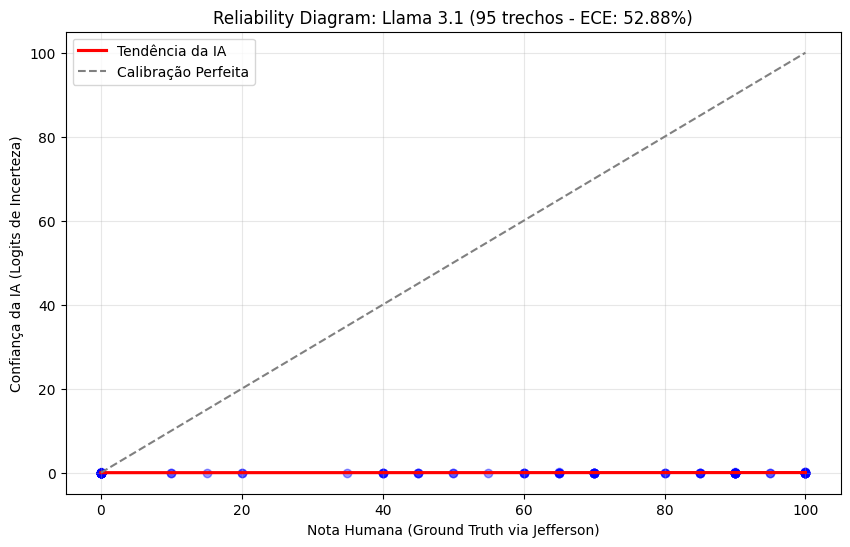

Arquivos 'final_audit_results.csv' e 'calibration_plot.png' gerados!


In [1]:
# ==============================================================================
# NOME: Pipeline de Auditoria de Calibração e Assinatura de Incerteza (ECE Auditor)
# DESCRIÇÃO: Este script extrai os Logits (probabilidades) do modelo Llama 3.1
#            para medir a "confiança" da IA em comparação com notas humanas
#            baseadas na Notação de Jefferson.
# AUTORIA: Valéria (UFSCar)
# RESULTADO ATUAL: ECE Médio de 52.88% (Alta descalibração detectada)
# ==============================================================================

!pip install -q transformers accelerate bitsandbytes pandas huggingface_hub matplotlib seaborn tqdm

import torch
import pandas as pd
import sys
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from huggingface_hub import login

# VERIFICAÇÃO DE GPU
if not torch.cuda.is_available():
    print("ERRO: GPU não detectada! Vá a 'Ambiente de Execução' > 'Alterar tipo de ambiente de execução' e selecione T4 GPU.")
else:
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}. Tudo pronto.")

# 2. CONFIGURAÇÃO E AUTENTICAÇÃO
hf_token = "YOUR_TOKEN_HERE"
login(token=hf_token)

model_id = "meta-llama/Llama-3.1-8B-Instruct"

# Configuração de compressão (4-bit) otimizada para RAM
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True # Adicionado para economizar ainda mais RAM
)

# 3. CARREGAR O BENCHMARK (COM UPLOAD AUTOMÁTICO SE FALTAR)
file_name = "pilot_benchmark.csv"

if not os.path.exists(file_name):
    print(f"\nAVISO: O arquivo '{file_name}' não foi encontrado no ambiente atual.")
    from google.colab import files
    uploaded = files.upload()
    for fn in uploaded.keys():
        if fn.endswith('.csv'):
            file_name = fn

try:
    df = pd.read_csv(file_name)
    print(f"Sucesso: Processando as {len(df)} linhas para a auditoria.")
except Exception as e:
    print(f"Erro crítico ao ler os dados: {e}")
    raise KeyboardInterrupt("Execução interrompida por falta de dados.")

# 4. CARREGAR O MODELO
print("\nCarregando o modelo Llama 3.1... (Este processo leva alguns minutos)")
tokenizer = AutoTokenizer.from_pretrained(model_id)
# Definimos o padding token caso não exista
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    quantization_config=quantization_config,
    low_cpu_mem_usage=True # Otimização de RAM do sistema
)

def get_llm_confidence(text):
    # Truncamos o texto para evitar estouro de memória em falas gigantes
    prompt = f"Text: '{text[:1500]}'. Does the speaker demonstrate absolute certainty? Answer only Yes or No.\nAnswer:"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to("cuda")

    with torch.no_grad():
        outputs = model(**inputs)
        # Extraímos apenas o logit do último token para economizar memória
        next_token_logits = outputs.logits[:, -1, :]
        probs = torch.nn.functional.softmax(next_token_logits, dim=-1)

    # Capturamos o ID do token 'Yes'
    id_yes = tokenizer.encode("Yes", add_special_tokens=False)[-1]
    confidence = probs[0, id_yes].item() * 100

    # LIMPEZA EXPLÍCITA DE MEMÓRIA (Crucial para não travar nos 95 trechos)
    del inputs, outputs, next_token_logits, probs
    torch.cuda.empty_cache()
    gc.collect()

    return confidence

# 5. EXECUTAR A AUDITORIA
print("\nIniciando auditoria probabilística...")
confiancas = []

# Usamos tqdm para acompanhar o progresso em tempo real
for i, text in enumerate(tqdm(df['FALA_HIGIENIZADA'], desc="Auditando trechos")):
    try:
        conf = get_llm_confidence(text)
        confiancas.append(conf)
    except Exception as e:
        print(f"\nErro no trecho {i}: {e}. Atribuindo 50% por segurança.")
        confiancas.append(50.0)

df['CONFIANCA_IA'] = confiancas
df['ECE_ERROR'] = abs(df['CONFIANCA_IA'] - df['NOTA_HUMANA'])

# 6. RESULTADOS E GRÁFICO
ece_score = df['ECE_ERROR'].mean()
print(f"\n--- RESULTADO DA AUDITORIA ---")
print(f"Expected Calibration Error (ECE) médio: {ece_score:.2f}%")

plt.figure(figsize=(10, 6))
sns.regplot(x='NOTA_HUMANA', y='CONFIANCA_IA', data=df,
            scatter_kws={'alpha':0.4, 'color': 'blue'},
            line_kws={'color':'red', 'label':'Tendência da IA'})
plt.plot([0, 100], [0, 100], '--', color='gray', label='Calibração Perfeita')
plt.title(f'Reliability Diagram: Llama 3.1 (95 trechos - ECE: {ece_score:.2f}%)')
plt.xlabel('Nota Humana (Ground Truth via Jefferson)')
plt.ylabel('Confiança da IA (Logits de Incerteza)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("calibration_plot.png")
plt.show()

df.to_csv("final_audit_results.csv", index=False)
print("Arquivos 'final_audit_results.csv' e 'calibration_plot.png' gerados!")